# Práctica 9: Análisis de texto

Para esta novena práctica, se ejecuta código para realizar un análisis de texto en las columnas del dataset, esto para identificar los valores más frecuentes dentro de las variables categóricas.

## Librerías

Se importan las librerías necesarias.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## Importación de los datos desde CSV

Se crea una copia del dataset limpio para manejarlo.

In [45]:
# Se carga el conjunto de datos limpio.
df_original = pd.read_csv("C:\\Users\\Paty-\\OneDrive\\Documentos\\04 Facultad\\Séptimo Semestre\\Minería de Datos\\CardiovascularDiseaseDataMining\\Practica1\\cardiovascular_disease_cleaned.csv", sep=";")

# Se crea una copia del conjunto de datos limpio para trabajar en ella.
df = df_original.copy()

# Se muestran las primeras filas del conjunto de datos.
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,birth_date,age_scaled,height_scaled,weight_scaled,ap_hi_scaled,ap_lo_scaled
0,0,50,Male,168,62.0,110,80,Normal,Normal,No,No,Yes,No,1968-10-15 09:32:17.835072,-0.426244,0.477190,-0.911143,-1.149090,-0.221435
1,1,55,Female,156,85.0,140,90,Well Above Normal,Normal,No,No,Yes,Yes,1963-10-07 09:32:17.835072,0.315922,-1.116157,0.963057,0.950300,1.081779
2,2,51,Female,165,64.0,130,70,Well Above Normal,Normal,No,No,No,Yes,1967-07-09 09:32:17.835072,-0.277811,0.078853,-0.748169,0.250504,-1.524649
3,3,48,Male,169,82.0,150,100,Normal,Normal,No,No,Yes,Yes,1970-11-24 09:32:17.835072,-0.723111,0.609969,0.718596,1.650097,2.384993
4,8,59,Female,151,67.0,120,80,Above Normal,Above Normal,No,No,No,No,1959-02-24 09:32:17.835072,0.909656,-1.780052,-0.503708,-0.449293,-0.221435


## Unión de columnas categóricas

Ya que el dataset no presenta una columna ya lista para utilizar, unimos algunas columnas categóricas para extraer información.

Tomamos únicamente los casos de riesgo.

In [46]:
df_cardio_yes = df[df['cardio'] == 'Yes']
df_cardio_no  = df[df['cardio'] == 'No']

text_data_yes = []
for _, row in df_cardio_yes.iterrows():
    if row['cholesterol'] != 'Normal':
        text_data_yes.append(f"cholesterol_{row['cholesterol']}")
    if row['gluc'] != 'Normal':
        text_data_yes.append(f"gluc_{row['gluc']}")
    if row['active'] == 'No':
        text_data_yes.append("active_No")
    if row['smoke'] == 'Yes':
        text_data_yes.append("smoke_Yes")
    if row['alco'] == 'Yes':
        text_data_yes.append("alco_Yes")

text_data_no = []
for _, row in df_cardio_no.iterrows():
    if row['cholesterol'] != 'Normal':
        text_data_no.append(f"cholesterol_{row['cholesterol']}")
    if row['gluc'] != 'Normal':
        text_data_no.append(f"gluc_{row['gluc']}")
    if row['active'] == 'No':
        text_data_no.append("active_No")
    if row['smoke'] == 'Yes':
        text_data_no.append("smoke_Yes")
    if row['alco'] == 'Yes':
        text_data_no.append("alco_Yes")

text_yes = ' '.join(text_data_yes)
text_no  = ' '.join(text_data_no)

## Creación y visualización de Word Cloud

Se crea una nube de palabras para visualizar las palabras más frecuentes presentes en los datos.

El tamaño de cada palabra representa su frecuencia dentro del conjunto de datos.

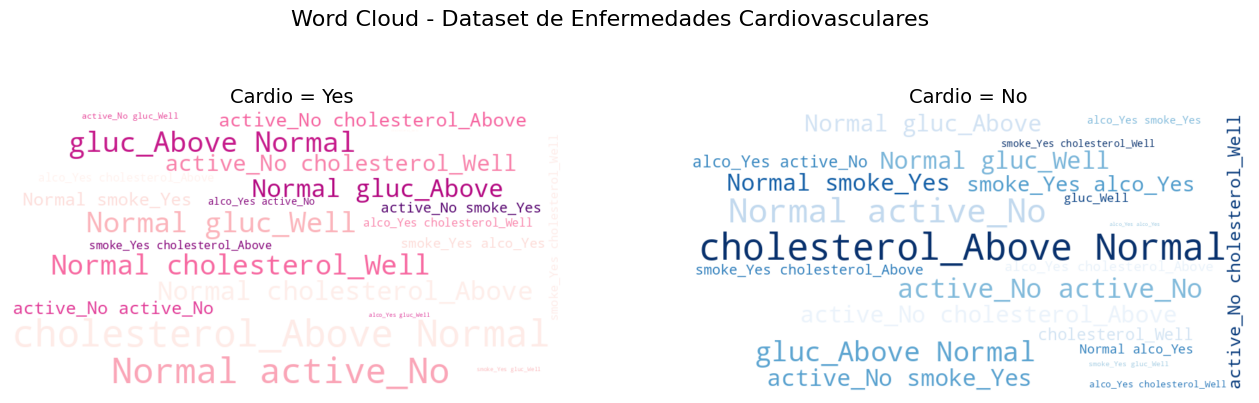

In [47]:
wordcloud_yes = WordCloud(width=800, height=400, background_color='white', colormap='RdPu').generate(text_yes)
wordcloud_no  = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(text_no)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wordcloud_yes, interpolation='bilinear')
axes[0].axis("off")
axes[0].set_title("Cardio = Yes", fontsize=14)

axes[1].imshow(wordcloud_no, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title("Cardio = No", fontsize=14)

plt.suptitle("Word Cloud - Dataset de Enfermedades Cardiovasculares", fontsize=16)
plt.show()